# 네이버 검색량 분석 - 연착륙 제품 146개 시각화

**분석일**: 2026-02-27

**목적**: SLI 연착륙 제품 146개의 검색량 데이터(블로그/쇼핑/뉴스)를 시각화하여 채널별 특성과 제품별 검색 패턴 파악

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# 한글 폰트 설정
import platform
if platform.system() == 'Darwin':  # macOS
    plt.rc('font', family='AppleGothic')
elif platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)  # 마이너스 기호 깨짐 방지

# 경로 설정
BASE_DIR = Path('/Users/yu_seok/Documents/문서 - Mac/workspace/01_현재진행/01_nbCamp/nb_Project/Why-pi')
DATA_DIR = BASE_DIR / '02_outputs' / 'Search_Trend'
FIG_DIR = BASE_DIR / '02_outputs' / '01_figures' / 'search_volume' / 'soft_landing'
FIG_DIR.mkdir(parents=True, exist_ok=True)

# 스타일 설정
sns.set_style('whitegrid')
COLORS = {
    'blog': '#1f77b4',  # 파란색
    'shop': '#ff7f0e',  # 주황색
    'news': '#2ca02c'   # 초록색
}

print('환경 설정 완료')

환경 설정 완료


In [2]:
# 데이터 로드
df_summary = pd.read_csv(DATA_DIR / 'search_volume_soft_landing_summary_20260227.csv')
df_detail = pd.read_csv(DATA_DIR / 'search_volume_soft_landing_detail_20260227.csv')

print(f'요약 데이터: {len(df_summary)}개 제품')
print(f'상세 데이터: {len(df_detail)}개 키워드')
print('\n요약 데이터 샘플:')
df_summary.head()

요약 데이터: 146개 제품
상세 데이터: 566개 키워드

요약 데이터 샘플:


,product_code,product_name,brand_name,keyword,blog_count,shop_count,news_count,total_count
0,1055367,더마블록 수분 선크림 35 ml (by 셀퓨전씨),더마블록,더마블록 더마블록 수분 선크림,460294,72,18,460384
1,1035082,딥 클렌징 폼 150 ml,다이소,딥 클렌징 폼,213998,53599,6468,274065
2,1055362,더마블록 데일리 선크림 35 ml (by 셀퓨전씨),더마블록,더마블록 더마블록 데일리 선크림,159373,36,16,159425
3,1027327,바세린 마스크팩 집중보습,바세린,바세린 바세린 마스크팩 집중보습,144377,2845,65,147287
4,1039941,포인트 딥클린 클렌징 오일 100ml,포인트,포인트 포인트 딥클린 클렌징 오일,132162,325,201,132688


In [3]:
# 기본 통계
print('=== 채널별 총 검색량 ===')
total_blog = df_summary['blog_count'].sum()
total_shop = df_summary['shop_count'].sum()
total_news = df_summary['news_count'].sum()
total_all = df_summary['total_count'].sum()

print(f'블로그: {total_blog:,}건 ({total_blog/total_all*100:.1f}%)')
print(f'쇼핑: {total_shop:,}건 ({total_shop/total_all*100:.1f}%)')
print(f'뉴스: {total_news:,}건 ({total_news/total_all*100:.1f}%)')
print(f'총합: {total_all:,}건')

=== 채널별 총 검색량 ===
블로그: 2,358,870건 (92.3%)
쇼핑: 186,951건 (7.3%)
뉴스: 10,707건 (0.4%)
총합: 2,556,528건


## 1. 채널별 검색량 비중 (파이차트)

/var/folders/3b/mp7mjwzj0y38km8nrsylgq180000gn/T/ipykernel_50557/3035566652.py:34: UserWarning: Glyph 52292 (\N{HANGUL SYLLABLE CAE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3b/mp7mjwzj0y38km8nrsylgq180000gn/T/ipykernel_50557/3035566652.py:34: UserWarning: Glyph 45328 (\N{HANGUL SYLLABLE NEOL}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3b/mp7mjwzj0y38km8nrsylgq180000gn/T/ipykernel_50557/3035566652.py:34: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3b/mp7mjwzj0y38km8nrsylgq180000gn/T/ipykernel_50557/3035566652.py:34: UserWarning: Glyph 44160 (\N{HANGUL SYLLABLE GEOM}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3b/mp7mjwzj0y38km8nrsylgq180000gn/T/ipykernel_50557/3035566652.py:34: UserWarning: Glyph 49353 (\N{HANGUL SYLLABLE SAEG}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3b/mp7mjwzj0y38km8nrsylgq180000gn/T/ipykernel_50557/3035566652.py:3

/opt/miniconda3/envs/py_study/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52292 (\N{HANGUL SYLLABLE CAE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/py_study/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45328 (\N{HANGUL SYLLABLE NEOL}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/py_study/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/py_study/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44160 (\N{HANGUL SYLLABLE GEOM}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/py_study/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49353 (\N{HANGUL SYLLABLE SAEG}) missi

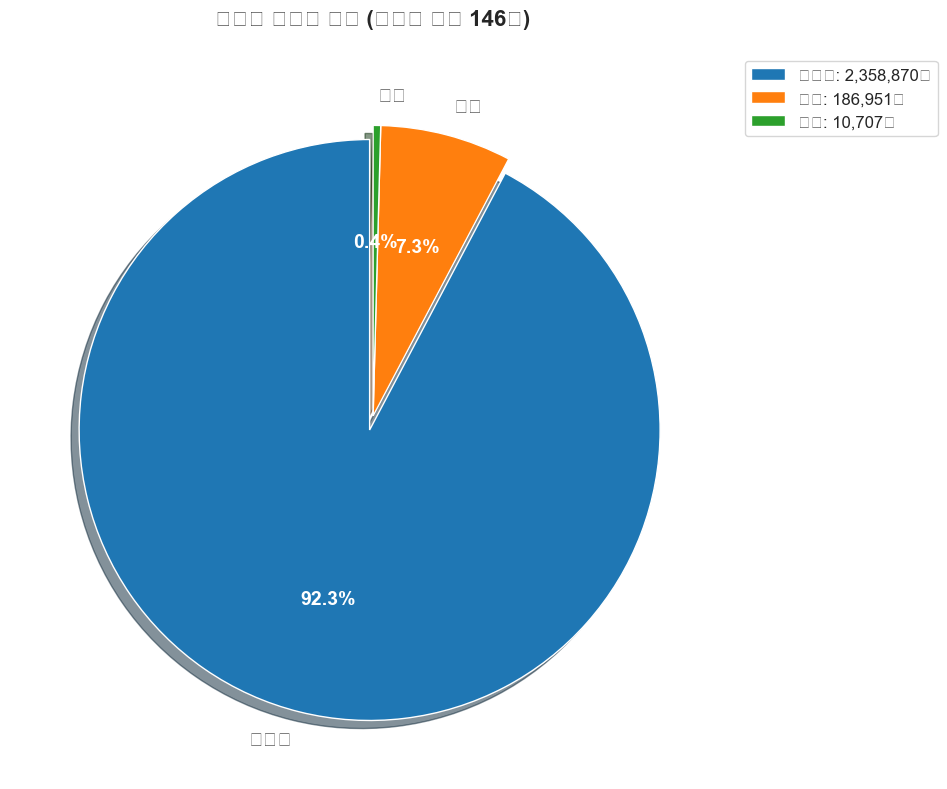

✅ 1번 차트 저장 완료: 01_channel_distribution.png


In [4]:
# 1. 채널별 검색량 비중 (파이차트)
fig, ax = plt.subplots(figsize=(10, 8))

sizes = [total_blog, total_shop, total_news]
labels = ['블로그', '쇼핑', '뉴스']
colors = [COLORS['blog'], COLORS['shop'], COLORS['news']]
explode = (0.05, 0, 0)  # 블로그 강조

wedges, texts, autotexts = ax.pie(
    sizes, 
    labels=labels, 
    colors=colors,
    autopct='%1.1f%%',
    explode=explode,
    shadow=True,
    startangle=90,
    textprops={'fontsize': 14, 'weight': 'bold'}
)

# 비율 텍스트 색상 조정
for autotext in autotexts:
    autotext.set_color('white')

ax.set_title('채널별 검색량 비중 (연착륙 제품 146개)', fontsize=16, weight='bold', pad=20)

# 범례 추가
ax.legend(
    [f'{label}: {size:,}건' for label, size in zip(labels, sizes)],
    loc='upper left',
    bbox_to_anchor=(1, 1),
    fontsize=12
)

plt.tight_layout()
plt.savefig(FIG_DIR / '01_channel_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print('✅ 1번 차트 저장 완료: 01_channel_distribution.png')

## 2. 검색량 TOP 20 제품 (수평 바차트)

/var/folders/3b/mp7mjwzj0y38km8nrsylgq180000gn/T/ipykernel_50557/1449779286.py:26: UserWarning: Glyph 44160 (\N{HANGUL SYLLABLE GEOM}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3b/mp7mjwzj0y38km8nrsylgq180000gn/T/ipykernel_50557/1449779286.py:26: UserWarning: Glyph 49353 (\N{HANGUL SYLLABLE SAEG}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3b/mp7mjwzj0y38km8nrsylgq180000gn/T/ipykernel_50557/1449779286.py:26: UserWarning: Glyph 47049 (\N{HANGUL SYLLABLE RYANG}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3b/mp7mjwzj0y38km8nrsylgq180000gn/T/ipykernel_50557/1449779286.py:26: UserWarning: Glyph 44148 (\N{HANGUL SYLLABLE GEON}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3b/mp7mjwzj0y38km8nrsylgq180000gn/T/ipykernel_50557/1449779286.py:26: UserWarning: Glyph 45908 (\N{HANGUL SYLLABLE DEO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3b/mp7mjwzj0y38km8nrsylgq180000gn/T/ipykernel_50557/1449779286.py:2

/opt/miniconda3/envs/py_study/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44160 (\N{HANGUL SYLLABLE GEOM}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/py_study/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49353 (\N{HANGUL SYLLABLE SAEG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/py_study/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47049 (\N{HANGUL SYLLABLE RYANG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/py_study/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44148 (\N{HANGUL SYLLABLE GEON}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/py_study/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45908 (\N{HANGUL SYLLABLE DEO}) missi

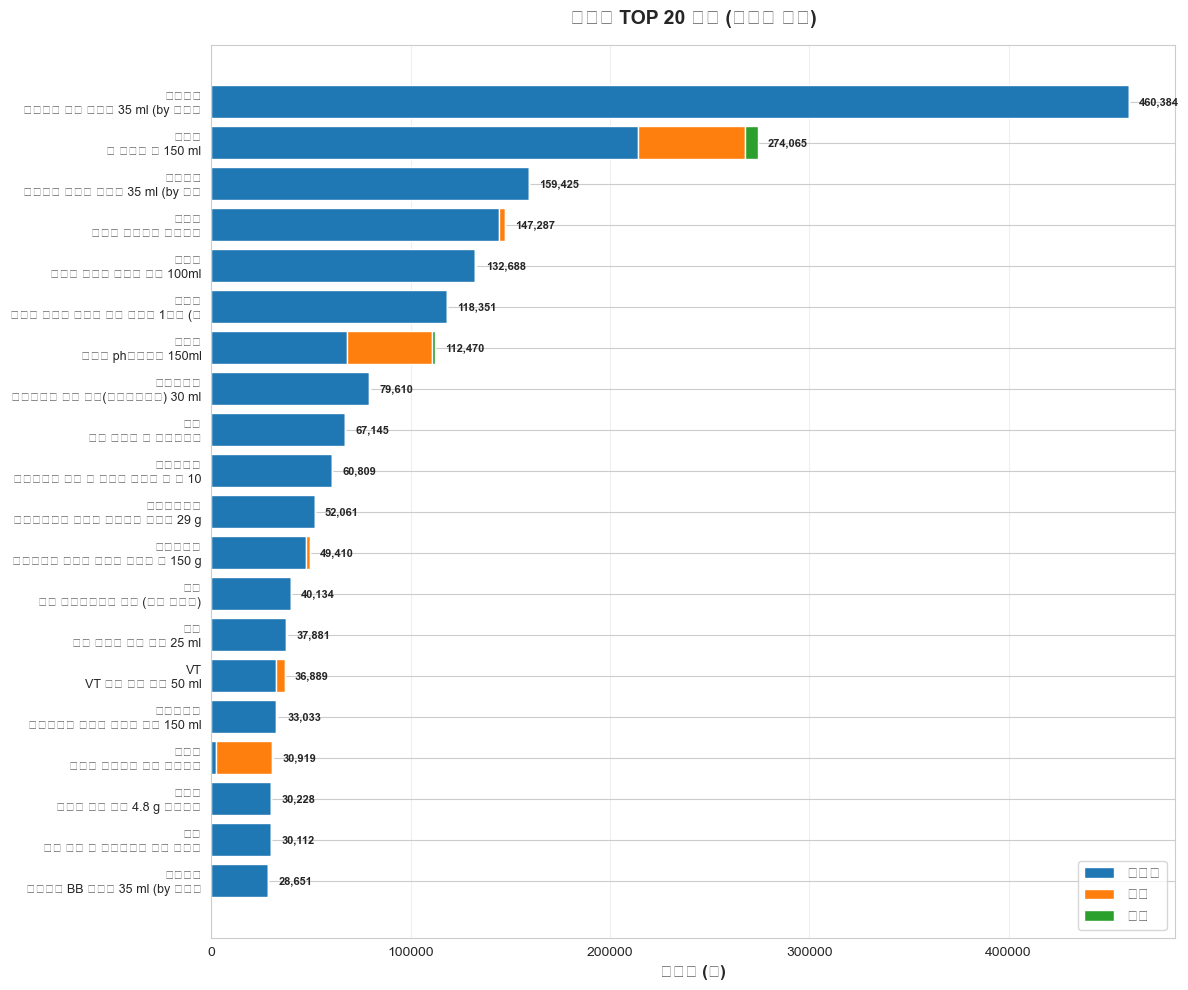

✅ 2번 차트 저장 완료: 02_top20_products.png


In [5]:
# 2. 검색량 TOP 20 제품 (스택 바차트)
top20 = df_summary.nlargest(20, 'total_count').copy()
top20['label'] = top20['brand_name'] + '\n' + top20['product_name'].str[:25]

fig, ax = plt.subplots(figsize=(12, 10))

# 스택 바차트
y_pos = np.arange(len(top20))
ax.barh(y_pos, top20['blog_count'], label='블로그', color=COLORS['blog'])
ax.barh(y_pos, top20['shop_count'], left=top20['blog_count'], label='쇼핑', color=COLORS['shop'])
ax.barh(y_pos, top20['news_count'], left=top20['blog_count']+top20['shop_count'], label='뉴스', color=COLORS['news'])

ax.set_yticks(y_pos)
ax.set_yticklabels(top20['label'].tolist(), fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('검색량 (건)', fontsize=12, weight='bold')
ax.set_title('검색량 TOP 20 제품 (채널별 분해)', fontsize=14, weight='bold', pad=15)
ax.legend(loc='lower right', fontsize=11)
ax.grid(axis='x', alpha=0.3)

# 총합 표시
for i, (idx, row) in enumerate(top20.iterrows()):
    ax.text(row['total_count'] + 5000, i, f"{row['total_count']:,}", 
            va='center', fontsize=8, weight='bold')

plt.tight_layout()
plt.savefig(FIG_DIR / '02_top20_products.png', dpi=300, bbox_inches='tight')
plt.show()

print('✅ 2번 차트 저장 완료: 02_top20_products.png')

## 3. 채널별 검색량 분포 (박스플롯)

/var/folders/3b/mp7mjwzj0y38km8nrsylgq180000gn/T/ipykernel_50557/1103003069.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/3b/mp7mjwzj0y38km8nrsylgq180000gn/T/ipykernel_50557/1103003069.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f'{int(10**y):,}' for y in yticks])
/var/folders/3b/mp7mjwzj0y38km8nrsylgq180000gn/T/ipykernel_50557/1103003069.py:35: UserWarning: Glyph 48660 (\N{HANGUL SYLLABLE BEUL}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3b/mp7mjwzj0y38km8nrsylgq180000gn/T/ipykernel_50557/1103003069.py:35: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3b/mp7mjwzj0y38km8nrsylgq180000gn/T/ipykernel_50557/1103003069.py:35: U

/opt/miniconda3/envs/py_study/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48660 (\N{HANGUL SYLLABLE BEUL}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/py_study/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/py_study/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44536 (\N{HANGUL SYLLABLE GEU}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/py_study/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49660 (\N{HANGUL SYLLABLE SYO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/py_study/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54609 (\N{HANGUL SYLLABLE PING}) missing f

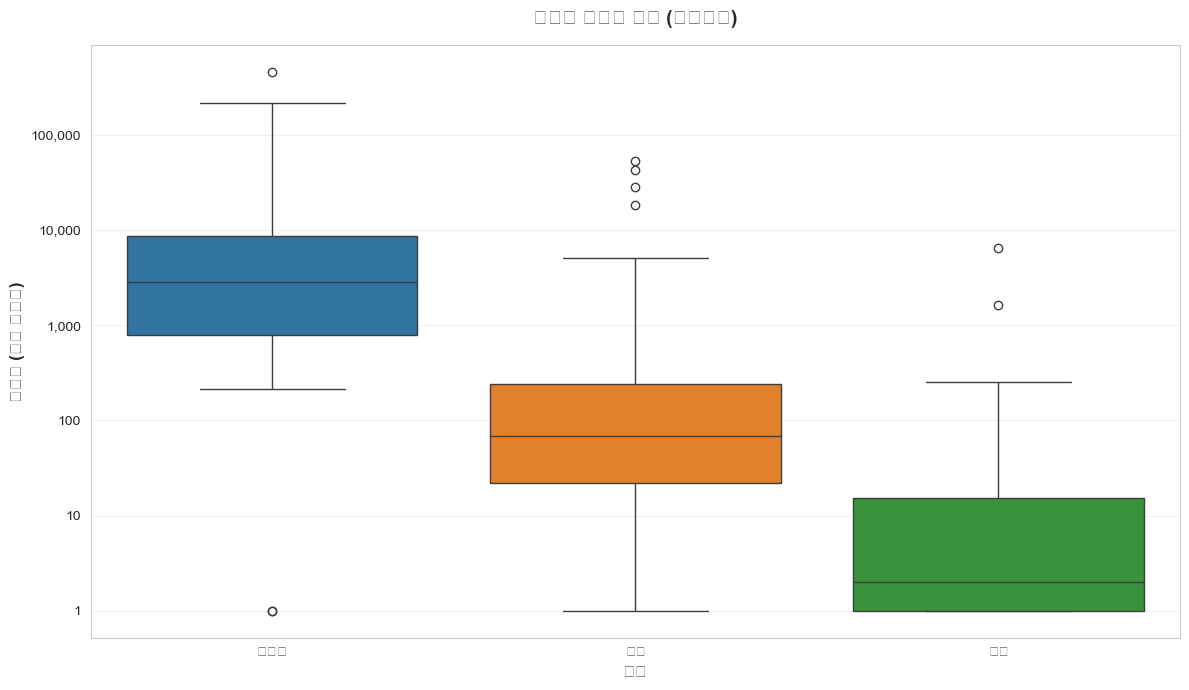

✅ 3번 차트 저장 완료: 03_channel_boxplot.png


In [6]:
# 3. 채널별 검색량 분포 (박스플롯)
df_melt = df_summary[['product_name', 'blog_count', 'shop_count', 'news_count']].melt(
    id_vars='product_name',
    var_name='channel',
    value_name='count'
)
df_melt['channel'] = df_melt['channel'].map({
    'blog_count': '블로그',
    'shop_count': '쇼핑',
    'news_count': '뉴스'
})

# 로그 변환 (0건 처리)
df_melt['log_count'] = np.log10(df_melt['count'] + 1)

fig, ax = plt.subplots(figsize=(12, 7))

sns.boxplot(
    data=df_melt,
    x='channel',
    y='log_count',
    palette=[COLORS['blog'], COLORS['shop'], COLORS['news']],
    ax=ax
)

ax.set_xlabel('채널', fontsize=12, weight='bold')
ax.set_ylabel('검색량 (로그 스케일)', fontsize=12, weight='bold')
ax.set_title('채널별 검색량 분포 (박스플롯)', fontsize=14, weight='bold', pad=15)
ax.grid(axis='y', alpha=0.3)

# Y축 레이블 변환
yticks = ax.get_yticks()
ax.set_yticklabels([f'{int(10**y):,}' for y in yticks])

plt.tight_layout()
plt.savefig(FIG_DIR / '03_channel_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

print('✅ 3번 차트 저장 완료: 03_channel_boxplot.png')

## 4. TOP 10 제품 채널별 분해 (스택 바)

/var/folders/3b/mp7mjwzj0y38km8nrsylgq180000gn/T/ipykernel_50557/438353837.py:27: UserWarning: Glyph 45908 (\N{HANGUL SYLLABLE DEO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3b/mp7mjwzj0y38km8nrsylgq180000gn/T/ipykernel_50557/438353837.py:27: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3b/mp7mjwzj0y38km8nrsylgq180000gn/T/ipykernel_50557/438353837.py:27: UserWarning: Glyph 48660 (\N{HANGUL SYLLABLE BEUL}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3b/mp7mjwzj0y38km8nrsylgq180000gn/T/ipykernel_50557/438353837.py:27: UserWarning: Glyph 47197 (\N{HANGUL SYLLABLE ROG}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3b/mp7mjwzj0y38km8nrsylgq180000gn/T/ipykernel_50557/438353837.py:27: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3b/mp7mjwzj0y38km8nrsylgq180000gn/T/ipykernel_50557/438353837.py:27: UserWarni

/opt/miniconda3/envs/py_study/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45908 (\N{HANGUL SYLLABLE DEO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/py_study/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/py_study/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48660 (\N{HANGUL SYLLABLE BEUL}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/py_study/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47197 (\N{HANGUL SYLLABLE ROG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/py_study/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing fro

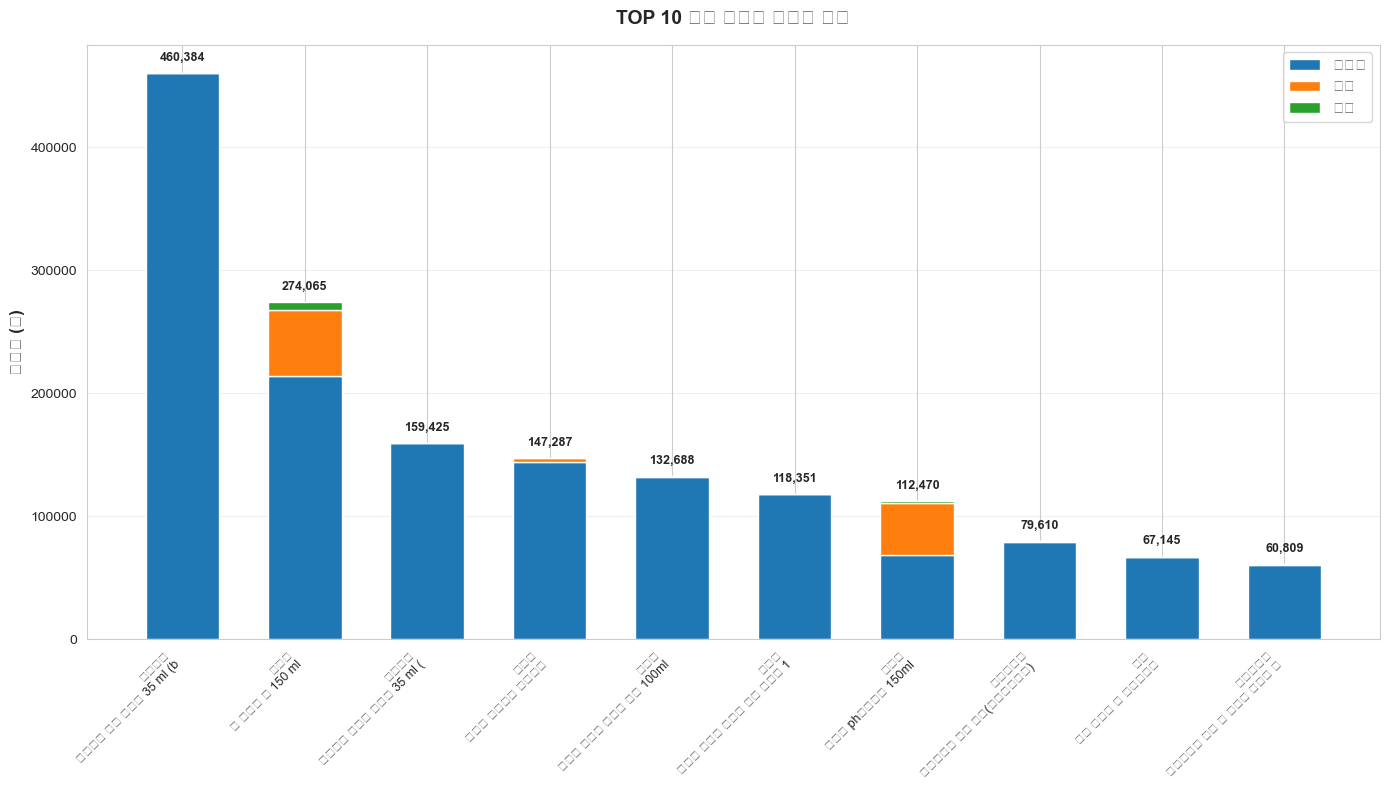

✅ 4번 차트 저장 완료: 04_top10_breakdown.png


In [7]:
# 4. TOP 10 제품 채널별 분해 (세로 스택 바)
top10 = df_summary.nlargest(10, 'total_count').copy()
top10['label'] = top10['brand_name'] + '\n' + top10['product_name'].str[:20]

fig, ax = plt.subplots(figsize=(14, 8))

x_pos = np.arange(len(top10))
width = 0.6

ax.bar(x_pos, top10['blog_count'], width, label='블로그', color=COLORS['blog'])
ax.bar(x_pos, top10['shop_count'], width, bottom=top10['blog_count'], label='쇼핑', color=COLORS['shop'])
ax.bar(x_pos, top10['news_count'], width, 
       bottom=top10['blog_count']+top10['shop_count'], label='뉴스', color=COLORS['news'])

ax.set_xticks(x_pos)
ax.set_xticklabels(top10['label'].tolist(), rotation=45, ha='right', fontsize=9)
ax.set_ylabel('검색량 (건)', fontsize=12, weight='bold')
ax.set_title('TOP 10 제품 채널별 검색량 분해', fontsize=14, weight='bold', pad=15)
ax.legend(loc='upper right', fontsize=11)
ax.grid(axis='y', alpha=0.3)

# 총합 표시
for i, (idx, row) in enumerate(top10.iterrows()):
    ax.text(i, row['total_count'] + 10000, f"{row['total_count']:,}", 
            ha='center', fontsize=9, weight='bold')

plt.tight_layout()
plt.savefig(FIG_DIR / '04_top10_breakdown.png', dpi=300, bbox_inches='tight')
plt.show()

print('✅ 4번 차트 저장 완료: 04_top10_breakdown.png')

## 5. 카테고리별 채널 특성 (그룹 바차트)

/var/folders/3b/mp7mjwzj0y38km8nrsylgq180000gn/T/ipykernel_50557/872278254.py:50: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3b/mp7mjwzj0y38km8nrsylgq180000gn/T/ipykernel_50557/872278254.py:50: UserWarning: Glyph 52992 (\N{HANGUL SYLLABLE KE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3b/mp7mjwzj0y38km8nrsylgq180000gn/T/ipykernel_50557/872278254.py:50: UserWarning: Glyph 50612 (\N{HANGUL SYLLABLE EO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3b/mp7mjwzj0y38km8nrsylgq180000gn/T/ipykernel_50557/872278254.py:50: UserWarning: Glyph 53364 (\N{HANGUL SYLLABLE KEUL}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3b/mp7mjwzj0y38km8nrsylgq180000gn/T/ipykernel_50557/872278254.py:50: UserWarning: Glyph 47116 (\N{HANGUL SYLLABLE REN}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3b/mp7mjwzj0y38km8nrsylgq180000gn/T/ipykernel_50557/872278254.py:50: UserWarn

/opt/miniconda3/envs/py_study/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/py_study/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52992 (\N{HANGUL SYLLABLE KE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/py_study/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50612 (\N{HANGUL SYLLABLE EO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/py_study/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 53364 (\N{HANGUL SYLLABLE KEUL}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/py_study/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47116 (\N{HANGUL SYLLABLE REN}) missing fr

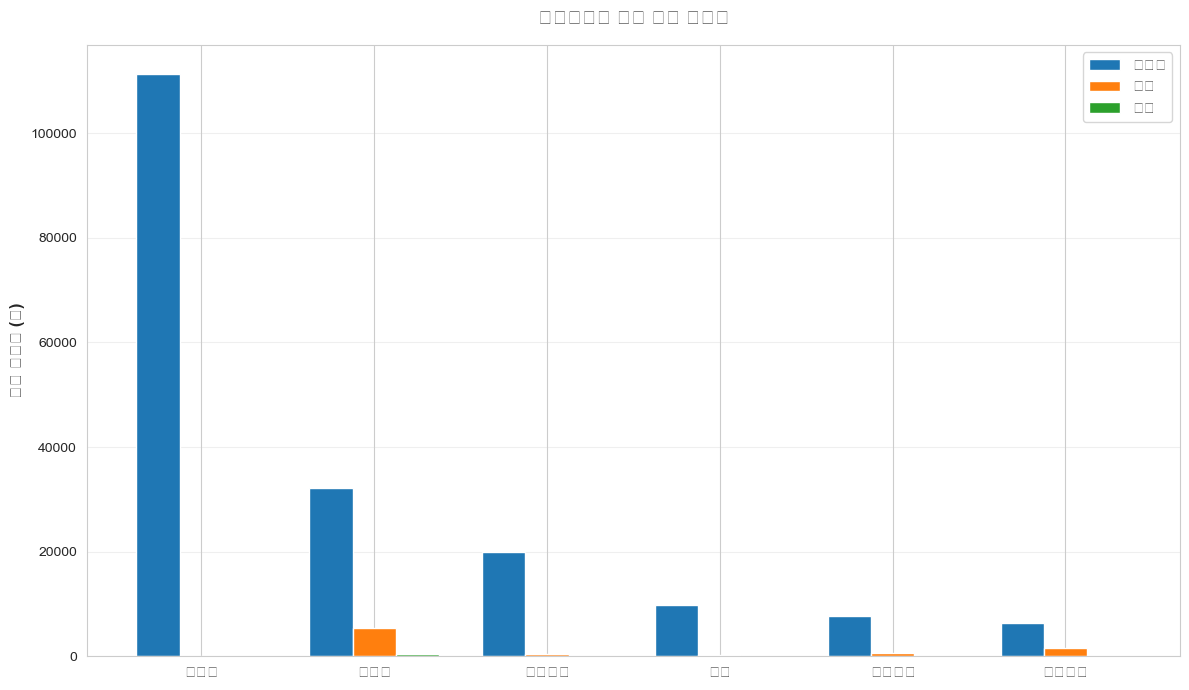

✅ 5번 차트 저장 완료: 05_category_channels.png


In [8]:
# 5. 카테고리별 채널 특성 (그룹 바차트)
# 카테고리 정보가 없으므로 브랜드명으로 추정
# 실제 사용 시 category_1 컬럼 추가 필요

# 임시: 제품명 기반 카테고리 추정
def infer_category(name):
    name_lower = name.lower()
    if any(k in name_lower for k in ['클렌징', '폼', '오일', '티슈']):
        return '클렌징'
    elif any(k in name_lower for k in ['선크림', '선스틱', '선쿠션', '자차']):
        return '선케어'
    elif any(k in name_lower for k in ['마스크팩', '팩']):
        return '마스크팩'
    elif any(k in name_lower for k in ['토너', '에센스', '크림', '젤', '앰플', '세럼', '로션']):
        return '스킨케어'
    elif any(k in name_lower for k in ['립', '마스카라', '아이라이너', '펜슬', '쿠션', '팩트', '파우더', '쉐딩']):
        return '메이크업'
    else:
        return '기타'

df_summary['category'] = df_summary['product_name'].apply(infer_category)

# 카테고리별 집계
cat_stats = df_summary.groupby('category').agg({
    'blog_count': 'mean',
    'shop_count': 'mean',
    'news_count': 'mean'
}).reset_index()

# 정렬 (총합 기준)
cat_stats['total'] = cat_stats['blog_count'] + cat_stats['shop_count'] + cat_stats['news_count']
cat_stats = cat_stats.sort_values('total', ascending=False)

fig, ax = plt.subplots(figsize=(12, 7))

x = np.arange(len(cat_stats))
width = 0.25

ax.bar(x - width, cat_stats['blog_count'], width, label='블로그', color=COLORS['blog'])
ax.bar(x, cat_stats['shop_count'], width, label='쇼핑', color=COLORS['shop'])
ax.bar(x + width, cat_stats['news_count'], width, label='뉴스', color=COLORS['news'])

ax.set_xticks(x)
ax.set_xticklabels(cat_stats['category'], fontsize=11)
ax.set_ylabel('평균 검색량 (건)', fontsize=12, weight='bold')
ax.set_title('카테고리별 채널 평균 검색량', fontsize=14, weight='bold', pad=15)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / '05_category_channels.png', dpi=300, bbox_inches='tight')
plt.show()

print('✅ 5번 차트 저장 완료: 05_category_channels.png')

## 6. 브랜드별 채널 전략 (히트맵)

/opt/miniconda3/envs/py_study/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 48660 (\N{HANGUL SYLLABLE BEUL}) missing from font(s) Arial.
  fig.canvas.draw()
/opt/miniconda3/envs/py_study/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) Arial.
  fig.canvas.draw()
/opt/miniconda3/envs/py_study/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 44536 (\N{HANGUL SYLLABLE GEU}) missing from font(s) Arial.
  fig.canvas.draw()
/opt/miniconda3/envs/py_study/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 49660 (\N{HANGUL SYLLABLE SYO}) missing from font(s) Arial.
  fig.canvas.draw()
/opt/miniconda3/envs/py_study/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 54609 (\N{HANGUL SYLLABLE PING}) missing from font(s) Arial.
  fig.canvas.draw()
/opt/miniconda3/envs/py_study/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 45684

/opt/miniconda3/envs/py_study/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48660 (\N{HANGUL SYLLABLE BEUL}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/py_study/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/py_study/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44536 (\N{HANGUL SYLLABLE GEU}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/py_study/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49660 (\N{HANGUL SYLLABLE SYO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/py_study/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54609 (\N{HANGUL SYLLABLE PING}) missing f

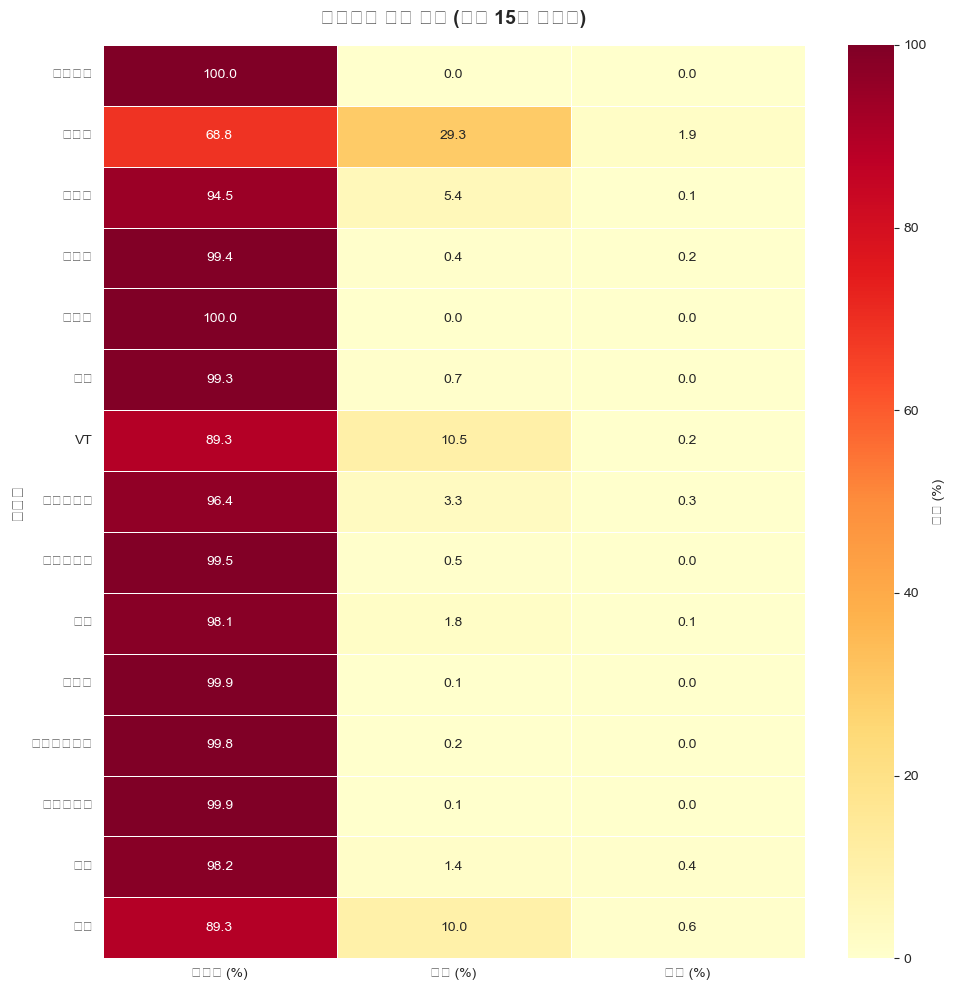

✅ 6번 차트 저장 완료: 06_brand_strategy_heatmap.png


In [9]:
# 6. 브랜드별 채널 전략 (히트맵)
# 브랜드별 채널 비중 계산
brand_stats = df_summary.groupby('brand_name').agg({
    'blog_count': 'sum',
    'shop_count': 'sum',
    'news_count': 'sum',
    'total_count': 'sum'
}).reset_index()

# 상위 15개 브랜드
top_brands = brand_stats.nlargest(15, 'total_count')

# 비중 계산
top_brands['blog_ratio'] = top_brands['blog_count'] / top_brands['total_count'] * 100
top_brands['shop_ratio'] = top_brands['shop_count'] / top_brands['total_count'] * 100
top_brands['news_ratio'] = top_brands['news_count'] / top_brands['total_count'] * 100

# 히트맵 데이터 준비
heatmap_data = top_brands[['brand_name', 'blog_ratio', 'shop_ratio', 'news_ratio']].set_index('brand_name')
heatmap_data.columns = ['블로그 (%)', '쇼핑 (%)', '뉴스 (%)']

fig, ax = plt.subplots(figsize=(10, 10))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    cbar_kws={'label': '비중 (%)'},
    linewidths=0.5,
    ax=ax
)

ax.set_title('브랜드별 채널 비중 (상위 15개 브랜드)', fontsize=14, weight='bold', pad=15)
ax.set_xlabel('')
ax.set_ylabel('브랜드', fontsize=12, weight='bold')

plt.tight_layout()
plt.savefig(FIG_DIR / '06_brand_strategy_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print('✅ 6번 차트 저장 완료: 06_brand_strategy_heatmap.png')

## 7. 키워드 패턴별 효율성 (바차트)

/var/folders/3b/mp7mjwzj0y38km8nrsylgq180000gn/T/ipykernel_50557/23858405.py:46: UserWarning: Glyph 48652 (\N{HANGUL SYLLABLE BEU}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3b/mp7mjwzj0y38km8nrsylgq180000gn/T/ipykernel_50557/23858405.py:46: UserWarning: Glyph 47004 (\N{HANGUL SYLLABLE RAEN}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3b/mp7mjwzj0y38km8nrsylgq180000gn/T/ipykernel_50557/23858405.py:46: UserWarning: Glyph 46300 (\N{HANGUL SYLLABLE DEU}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3b/mp7mjwzj0y38km8nrsylgq180000gn/T/ipykernel_50557/23858405.py:46: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3b/mp7mjwzj0y38km8nrsylgq180000gn/T/ipykernel_50557/23858405.py:46: UserWarning: Glyph 54408 (\N{HANGUL SYLLABLE PUM}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3b/mp7mjwzj0y38km8nrsylgq180000gn/T/ipykernel_50557/23858405.py:46: UserWarning: G

/opt/miniconda3/envs/py_study/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48652 (\N{HANGUL SYLLABLE BEU}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/py_study/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47004 (\N{HANGUL SYLLABLE RAEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/py_study/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 46300 (\N{HANGUL SYLLABLE DEU}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/py_study/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/py_study/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54408 (\N{HANGUL SYLLABLE PUM}) missing fr

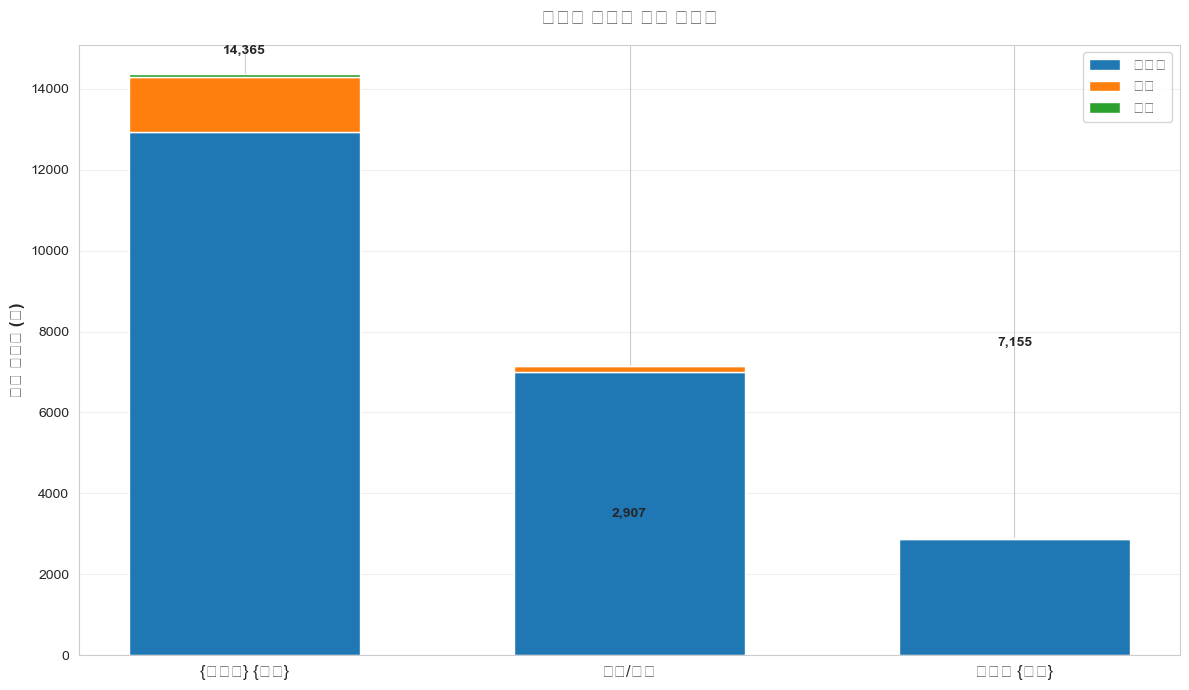

✅ 7번 차트 저장 완료: 07_keyword_efficiency.png


In [10]:
# 7. 키워드 패턴별 효율성 (바차트)
# 키워드 패턴 분류
def classify_keyword(keyword):
    if '후기' in keyword or '리뷰' in keyword:
        return '후기/리뷰'
    elif keyword.startswith('다이소'):
        return '다이소 {제품}'
    else:
        return '{브랜드} {제품}'

df_detail['pattern'] = df_detail['keyword'].apply(classify_keyword)

# 패턴별 평균 검색량
pattern_stats = df_detail.groupby('pattern').agg({
    'total_count': 'mean',
    'blog_count': 'mean',
    'shop_count': 'mean',
    'news_count': 'mean'
}).reset_index()

pattern_stats = pattern_stats.sort_values('total_count', ascending=False)

fig, ax = plt.subplots(figsize=(12, 7))

x_pos = np.arange(len(pattern_stats))
width = 0.6

ax.bar(x_pos, pattern_stats['blog_count'], width, label='블로그', color=COLORS['blog'])
ax.bar(x_pos, pattern_stats['shop_count'], width, 
       bottom=pattern_stats['blog_count'], label='쇼핑', color=COLORS['shop'])
ax.bar(x_pos, pattern_stats['news_count'], width, 
       bottom=pattern_stats['blog_count']+pattern_stats['shop_count'], label='뉴스', color=COLORS['news'])

ax.set_xticks(x_pos)
ax.set_xticklabels(pattern_stats['pattern'], fontsize=12)
ax.set_ylabel('평균 검색량 (건)', fontsize=12, weight='bold')
ax.set_title('키워드 패턴별 평균 검색량', fontsize=14, weight='bold', pad=15)
ax.legend(loc='upper right', fontsize=11)
ax.grid(axis='y', alpha=0.3)

# 총합 표시
for i, row in pattern_stats.iterrows():
    ax.text(i, row['total_count'] + 500, f"{row['total_count']:,.0f}", 
            ha='center', fontsize=10, weight='bold')

plt.tight_layout()
plt.savefig(FIG_DIR / '07_keyword_efficiency.png', dpi=300, bbox_inches='tight')
plt.show()

print('✅ 7번 차트 저장 완료: 07_keyword_efficiency.png')

## 8. 검색량 vs DataLab 순위 비교 (산점도)

**주의**: DataLab avg_ratio 데이터가 없으므로 임시로 총 검색량 기반으로 순위 비교

/var/folders/3b/mp7mjwzj0y38km8nrsylgq180000gn/T/ipykernel_50557/593574368.py:35: UserWarning: Glyph 48660 (\N{HANGUL SYLLABLE BEUL}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3b/mp7mjwzj0y38km8nrsylgq180000gn/T/ipykernel_50557/593574368.py:35: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3b/mp7mjwzj0y38km8nrsylgq180000gn/T/ipykernel_50557/593574368.py:35: UserWarning: Glyph 44536 (\N{HANGUL SYLLABLE GEU}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3b/mp7mjwzj0y38km8nrsylgq180000gn/T/ipykernel_50557/593574368.py:35: UserWarning: Glyph 44160 (\N{HANGUL SYLLABLE GEOM}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3b/mp7mjwzj0y38km8nrsylgq180000gn/T/ipykernel_50557/593574368.py:35: UserWarning: Glyph 49353 (\N{HANGUL SYLLABLE SAEG}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/3b/mp7mjwzj0y38km8nrsylgq180000gn/T/ipykernel_50557/593574368.py:35: UserWa

/opt/miniconda3/envs/py_study/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48660 (\N{HANGUL SYLLABLE BEUL}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/py_study/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/py_study/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44536 (\N{HANGUL SYLLABLE GEU}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/py_study/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44160 (\N{HANGUL SYLLABLE GEOM}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/py_study/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49353 (\N{HANGUL SYLLABLE SAEG}) missing 

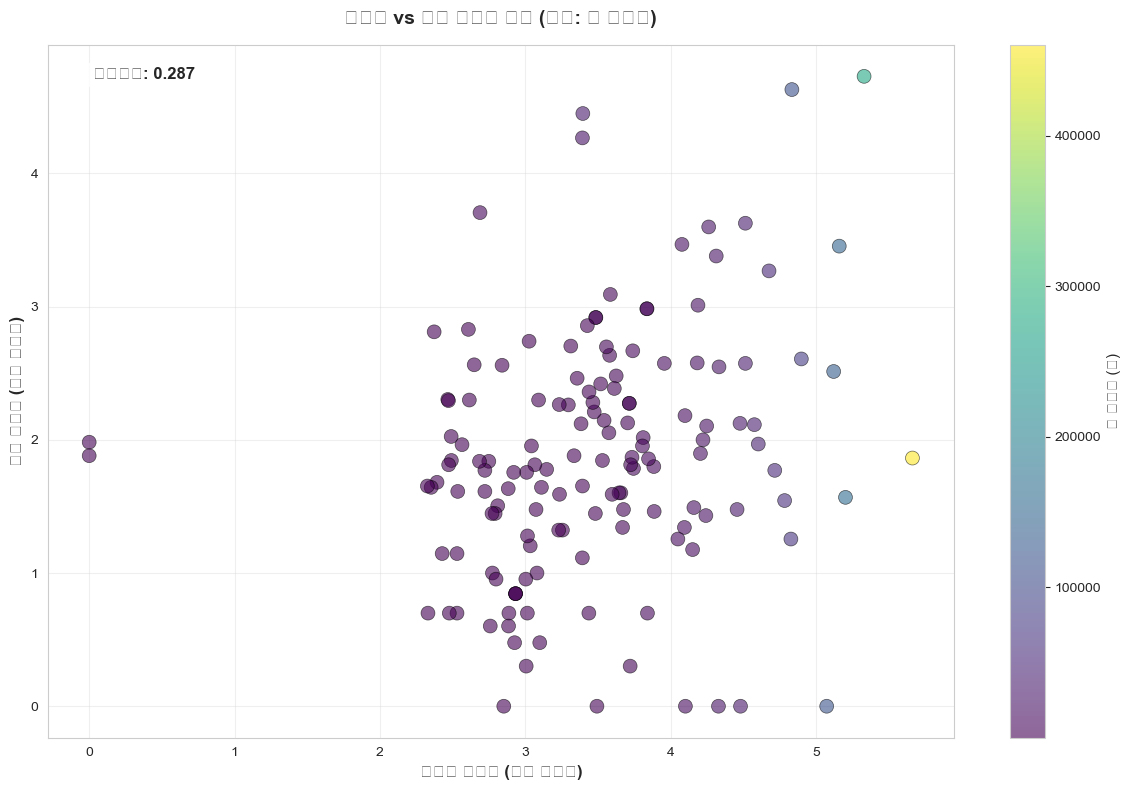

✅ 8번 차트 저장 완료: 08_blog_vs_shop_scatter.png

블로그-쇼핑 상관계수: 0.287


In [11]:
# 8. 검색량 분포 산점도 (DataLab 데이터 없으므로 대체)
# 블로그 vs 쇼핑 검색량 비교
fig, ax = plt.subplots(figsize=(12, 8))

# 로그 스케일 적용
df_summary['log_blog'] = np.log10(df_summary['blog_count'] + 1)
df_summary['log_shop'] = np.log10(df_summary['shop_count'] + 1)

scatter = ax.scatter(
    df_summary['log_blog'],
    df_summary['log_shop'],
    c=df_summary['total_count'],
    cmap='viridis',
    s=100,
    alpha=0.6,
    edgecolors='black',
    linewidth=0.5
)

ax.set_xlabel('블로그 검색량 (로그 스케일)', fontsize=12, weight='bold')
ax.set_ylabel('쇼핑 검색량 (로그 스케일)', fontsize=12, weight='bold')
ax.set_title('블로그 vs 쇼핑 검색량 분포 (색상: 총 검색량)', fontsize=14, weight='bold', pad=15)
ax.grid(True, alpha=0.3)

# 컬러바
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('총 검색량 (건)', fontsize=11)

# 상관계수
corr = df_summary['blog_count'].corr(df_summary['shop_count'])
ax.text(0.05, 0.95, f'상관계수: {corr:.3f}', 
        transform=ax.transAxes, fontsize=12, weight='bold',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig(FIG_DIR / '08_blog_vs_shop_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

print('✅ 8번 차트 저장 완료: 08_blog_vs_shop_scatter.png')
print(f'\n블로그-쇼핑 상관계수: {corr:.3f}')

## 완료 요약

In [12]:
print('\n' + '='*60)
print('✅ 시각화 8개 차트 생성 완료')
print('='*60)
print(f'저장 경로: {FIG_DIR}')
print('\n생성된 파일:')
for i, fname in enumerate(sorted(FIG_DIR.glob('*.png')), 1):
    print(f'  {i}. {fname.name}')
print('\n다음 단계: 문서에 이미지 삽입')


✅ 시각화 8개 차트 생성 완료
저장 경로: /Users/yu_seok/Documents/문서 - Mac/workspace/01_현재진행/01_nbCamp/nb_Project/Why-pi/02_outputs/01_figures/search_volume/soft_landing

생성된 파일:
  1. 01_channel_distribution.png
  2. 02_top20_products.png
  3. 03_channel_boxplot.png
  4. 04_top10_breakdown.png
  5. 05_category_channels.png
  6. 06_brand_strategy_heatmap.png
  7. 07_keyword_efficiency.png
  8. 08_blog_vs_shop_scatter.png

다음 단계: 문서에 이미지 삽입
